# Environment

In [1]:
import os
os.chdir("..")

In [2]:
import pandas as pd
from sklearn.metrics import classification_report

from src.pipeline.llm import ModelConfig, PromptConfig, ChatTemplatePipeline

from src.utils.map import SYMPTOM_MAP
from src.utils.prompt import load_prompt, user_prompt

In [3]:
LABEL_CLASSES = list(SYMPTOM_MAP.values())

## Data Load

In [4]:
df = pd.read_csv("./data/processed/amive.csv")

## Prompt Config

In [5]:
prompt_zero_shot_cfg = PromptConfig(
    system_prompt=load_prompt("./prompts/zero_shot.txt"),
    user_prompt=user_prompt,
    batch_size=1,
    text_col="TEXT",
)

In [6]:
prompt_few_shot_cfg = PromptConfig(
    system_prompt=load_prompt("./prompts/few_shot.txt"),
    user_prompt=user_prompt,
    batch_size=1,
    text_col="TEXT",
)

## Model Config

In [7]:
model_cfg = ModelConfig(
    model_name="Qwen_2.5-72B-AWQ",
    model_path="Qwen/Qwen2.5-72B-Instruct-AWQ", 
    label_classes=LABEL_CLASSES,
    max_new_tokens=48,
    do_sample=False,
    device_map="cuda:0"
)

In [8]:
pipeline = ChatTemplatePipeline(model_cfg)

## Y_True

In [9]:
y_true = df[LABEL_CLASSES]

## Zero-Shot

In [10]:
zero_shot = pipeline.run(df, prompt_zero_shot_cfg, verbose=True)

DEBUG:httpcore.connection:connect_tcp.started host='huggingface.co' port=443 local_address=None timeout=10 socket_options=None
DEBUG:httpcore.connection:connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x7910017f57c0>
DEBUG:httpcore.connection:start_tls.started ssl_context=<ssl.SSLContext object at 0x79100150e050> server_hostname='huggingface.co' timeout=10
DEBUG:httpcore.connection:start_tls.complete return_value=<httpcore._backends.sync.SyncStream object at 0x7910018857f0>
DEBUG:httpcore.http11:send_request_headers.started request=<Request [b'HEAD']>
DEBUG:httpcore.http11:send_request_headers.complete
DEBUG:httpcore.http11:send_request_body.started request=<Request [b'HEAD']>
DEBUG:httpcore.http11:send_request_body.complete
DEBUG:httpcore.http11:receive_response_headers.started request=<Request [b'HEAD']>
DEBUG:httpcore.http11:receive_response_headers.complete return_value=(b'HTTP/1.1', 307, b'Temporary Redirect', [(b'Content-Type', b'text/plain; charse

WARN  Python GIL is enabled: Multi-gpu quant acceleration for MoE models is sub-optimal and multi-core accelerated cpu packing is also disabled. We recommend Python >= 3.13.3t with Pytorch > 2.8 for mult-gpu quantization and multi-cpu packing with env `PYTHON_GIL=0`.


INFO  ENV: Auto setting PYTORCH_ALLOC_CONF='expandable_segments:True,max_split_size_mb:256,garbage_collection_threshold:0.7' for memory saving.


INFO  ENV: Auto setting CUDA_DEVICE_ORDER=PCI_BUS_ID for correctness.          


DEBUG:datasets:PyTorch version 2.9.1 available.
fatal: not a git repository (or any parent up to mount point /)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


...

DEBUG:httpcore.http11:receive_response_body.started request=<Request [b'GET']>
DEBUG:httpcore.http11:receive_response_body.complete
DEBUG:httpcore.http11:response_closed.started
DEBUG:httpcore.http11:response_closed.complete
DEBUG:filelock:Attempting to release lock 133109631558736 on /home/leo/.cache/huggingface/hub/.locks/models--Qwen--Qwen2.5-72B-Instruct-AWQ/4783fe10ac3adce15ac8f358ef5462739852c569.lock
DEBUG:filelock:Lock 133109631558736 released on /home/leo/.cache/huggingface/hub/.locks/models--Qwen--Qwen2.5-72B-Instruct-AWQ/4783fe10ac3adce15ac8f358ef5462739852c569.lock
DEBUG:httpcore.http11:send_request_headers.started request=<Request [b'HEAD']>
DEBUG:httpcore.http11:send_request_headers.complete
DEBUG:httpcore.http11:send_request_body.started request=<Request [b'HEAD']>
DEBUG:httpcore.http11:send_request_body.complete
DEBUG:httpcore.http11:receive_response_headers.started request=<Request [b'HEAD']>
DEBUG:httpcore.http11:receive_response_headers.complete return_value=(b'HTTP/

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

DEBUG:httpcore.http11:receive_response_body.started request=<Request [b'GET']>
DEBUG:httpcore.http11:receive_response_body.complete
DEBUG:httpcore.http11:response_closed.started
DEBUG:httpcore.http11:response_closed.complete
DEBUG:filelock:Attempting to release lock 133109631558736 on /home/leo/.cache/huggingface/hub/.locks/models--Qwen--Qwen2.5-72B-Instruct-AWQ/31349551d90c7606f325fe0f11bbb8bd5fa0d7c7.lock
DEBUG:filelock:Lock 133109631558736 released on /home/leo/.cache/huggingface/hub/.locks/models--Qwen--Qwen2.5-72B-Instruct-AWQ/31349551d90c7606f325fe0f11bbb8bd5fa0d7c7.lock
DEBUG:httpcore.http11:send_request_headers.started request=<Request [b'HEAD']>
DEBUG:httpcore.http11:send_request_headers.complete
DEBUG:httpcore.http11:send_request_body.started request=<Request [b'HEAD']>
DEBUG:httpcore.http11:send_request_body.complete
DEBUG:httpcore.http11:receive_response_headers.started request=<Request [b'HEAD']>
DEBUG:httpcore.http11:receive_response_headers.complete return_value=(b'HTTP/

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

DEBUG:httpcore.http11:receive_response_body.started request=<Request [b'GET']>
DEBUG:httpcore.http11:receive_response_body.complete
DEBUG:httpcore.http11:response_closed.started
DEBUG:httpcore.http11:response_closed.complete
DEBUG:filelock:Attempting to release lock 133108310789872 on /home/leo/.cache/huggingface/hub/.locks/models--Qwen--Qwen2.5-72B-Instruct-AWQ/450c878a19e58fd31cdd5f99d9fea007e0d29771.lock
DEBUG:filelock:Lock 133108310789872 released on /home/leo/.cache/huggingface/hub/.locks/models--Qwen--Qwen2.5-72B-Instruct-AWQ/450c878a19e58fd31cdd5f99d9fea007e0d29771.lock
DEBUG:httpcore.http11:send_request_headers.started request=<Request [b'HEAD']>
DEBUG:httpcore.http11:send_request_headers.complete
DEBUG:httpcore.http11:send_request_body.started request=<Request [b'HEAD']>
DEBUG:httpcore.http11:send_request_body.complete
DEBUG:httpcore.http11:receive_response_headers.started request=<Request [b'HEAD']>
DEBUG:httpcore.http11:receive_response_headers.complete return_value=(b'HTTP/

In [11]:
y_pred_zero_shot = zero_shot["encoded"]

In [12]:
print(classification_report(y_true, y_pred_zero_shot, zero_division=0, target_names=LABEL_CLASSES))

              precision    recall  f1-score   support

           1       0.54      0.88      0.67       446
           2       0.57      0.90      0.70       333
           3       0.83      0.91      0.87       262
           4       0.61      0.76      0.67       212
           5       0.70      0.91      0.79       203
           6       0.36      0.63      0.46       161
           7       0.46      0.30      0.36       146
           8       0.88      0.25      0.39       142
           9       0.20      0.87      0.32       141

   micro avg       0.51      0.77      0.61      2046
   macro avg       0.57      0.71      0.58      2046
weighted avg       0.58      0.77      0.63      2046
 samples avg       0.55      0.77      0.62      2046



## Few-Shot

In [13]:
few_shot = pipeline.run(df, prompt_few_shot_cfg, verbose=True)

DEBUG:src.pipeline.llm:idx=0 | out='{"labels":[2,4,6]}' | parser=2,4,6
DEBUG:src.pipeline.llm:idx=1 | out='{"labels":[9]}' | parser=9
DEBUG:src.pipeline.llm:idx=2 | out='{"labels":[6]}' | parser=6
DEBUG:src.pipeline.llm:idx=3 | out='{"labels":[5]}' | parser=5
DEBUG:src.pipeline.llm:idx=4 | out='{"labels":[0]}' | parser=
DEBUG:src.pipeline.llm:idx=5 | out='{"labels":[6,9]}' | parser=6,9
DEBUG:src.pipeline.llm:idx=6 | out='{"labels":[1]}' | parser=1
DEBUG:src.pipeline.llm:idx=7 | out='{"labels":[1,9]}' | parser=1,9
DEBUG:src.pipeline.llm:idx=8 | out='{"labels":[1,2,9]}' | parser=1,2,9
DEBUG:src.pipeline.llm:idx=9 | out='{"labels":[2,4,9]}' | parser=2,4,9
DEBUG:src.pipeline.llm:idx=10 | out='{"labels":[0]}' | parser=
DEBUG:src.pipeline.llm:idx=11 | out='{"labels":[0]}' | parser=
DEBUG:src.pipeline.llm:idx=12 | out='{"labels":[2]}' | parser=2
DEBUG:src.pipeline.llm:idx=13 | out='{"labels":[0]}' | parser=
DEBUG:src.pipeline.llm:idx=14 | out='{"labels":[1,2,5,9]}' | parser=1,2,5,9
DEBUG:src.

In [14]:
y_pred_few_shot = few_shot["encoded"]

In [15]:
print(classification_report(y_true, y_pred_few_shot, zero_division=0, target_names=LABEL_CLASSES))

              precision    recall  f1-score   support

           1       0.75      0.79      0.77       446
           2       0.79      0.79      0.79       333
           3       0.82      0.92      0.87       262
           4       0.61      0.76      0.68       212
           5       0.66      0.89      0.76       203
           6       0.43      0.64      0.51       161
           7       0.55      0.26      0.35       146
           8       0.77      0.39      0.52       142
           9       0.28      0.84      0.42       141

   micro avg       0.62      0.74      0.67      2046
   macro avg       0.63      0.70      0.63      2046
weighted avg       0.67      0.74      0.68      2046
 samples avg       0.64      0.74      0.66      2046



# Analysis

DEBUG:matplotlib:matplotlib data path: /home/leo/.venv/lib/python3.12/site-packages/matplotlib/mpl-data
DEBUG:matplotlib:CONFIGDIR=/home/leo/.config/matplotlib
DEBUG:matplotlib:interactive is False
DEBUG:matplotlib:platform is linux
DEBUG:matplotlib:CACHEDIR=/home/leo/.cache/matplotlib
DEBUG:matplotlib.font_manager:Using fontManager instance from /home/leo/.cache/matplotlib/fontlist-v390.json
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/leo/.venv/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/cmtt10.ttf', name='cmtt10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_m

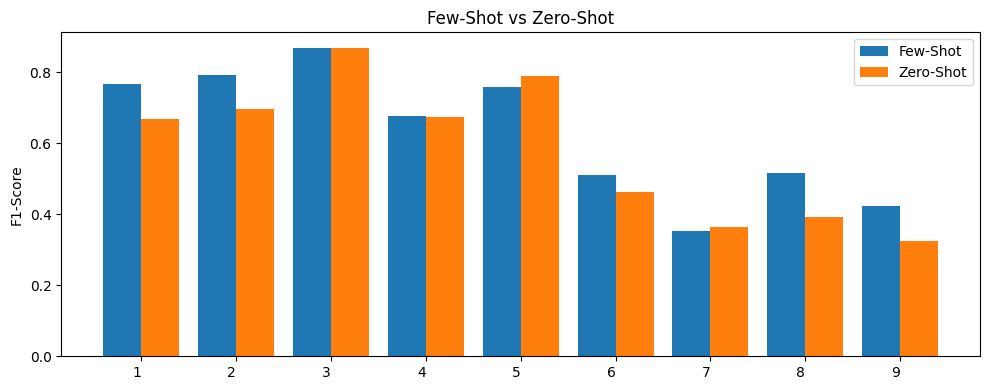

: 

In [ ]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

few  = [f1_score(y_true[l], y_pred_few_shot[l],  zero_division=0) for l in LABEL_CLASSES]
zero = [f1_score(y_true[l], y_pred_zero_shot[l], zero_division=0) for l in LABEL_CLASSES]

x = range(len(LABEL_CLASSES))
plt.figure(figsize=(10, 4))
plt.bar([i - 0.2 for i in x], few,  0.4, label="Few-Shot")
plt.bar([i + 0.2 for i in x], zero, 0.4, label="Zero-Shot")
plt.xticks(list(x), LABEL_CLASSES, ha="right")
plt.ylabel("F1-Score")
plt.title("Few-Shot vs Zero-Shot")
plt.legend()
plt.tight_layout()
plt.show()